In [12]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pgmpy.models import BayesianNetwork
import networkx as nx
import matplotlib.patches as mpatches
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [13]:
df = pd.concat([X, y], axis=1)

print("1. Dataset Overview")
print("-" * 50)
print("\nShape of the dataset:", df.shape)
print("\nFirst few rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())

print("\n2. Missing Values Analysis")
print("-" * 50)
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0] if len(missing_values[missing_values > 0]) > 0 else "No missing values found")

print("\n3. Statistical Summary")
print("-" * 50)
print(df.describe())

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation.png')
plt.close()

print("\n4. Feature-specific Analysis")
print("-" * 50)

print("\nDemographic Variables Analysis:")
print("\nGender Distribution (1 = male, 2 = female):")
print(df['X2'].value_counts(normalize=True))

print("\nEducation Distribution (1 = graduate, 2 = university, 3 = high school, 4 = others):")
print(df['X3'].value_counts(normalize=True))

print("\nMarital Status Distribution (1 = married, 2 = single, 3 = others):")
print(df['X4'].value_counts(normalize=True))

print("\nAge Statistics:")
print(df['X5'].describe())

print("\nPayment Status Distribution:")
payment_cols = ['X6', 'X7', 'X8', 'X9', 'X10', 'X11']
for col in payment_cols:
    print(f"\n{col} (Repayment Status):")
    print(df[col].value_counts().sort_index())

bill_amount_cols = ['X12', 'X13', 'X14', 'X15', 'X16', 'X17']
print("\nBill Amount Statistics:")
print(df[bill_amount_cols].describe())

pay_amount_cols = ['X18', 'X19', 'X20', 'X21', 'X22', 'X23']
print("\nPayment Amount Statistics:")
print(df[pay_amount_cols].describe())

print("\n5. Class Balance Analysis")
print("-" * 50)
print("\nDefault payment distribution:")
print(df['Y'].value_counts(normalize=True))


def detect_outliers(df, columns):
    outliers_summary = {}
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        outliers_summary[column] = len(outliers)
    return outliers_summary

numerical_cols = ['X1', 'X5'] + ['X12', 'X13', 'X14', 'X15', 'X16', 'X17'] + ['X18', 'X19', 'X20', 'X21', 'X22', 'X23']
outliers = detect_outliers(df, numerical_cols)

print("\n6. Outlier Analysis")
print("-" * 50)
print("\nNumber of outliers per numerical column:")
for col, count in outliers.items():
    print(f"{col}: {count} outliers")

print("\n7. Scale Analysis")
print("-" * 50)
numerical_summary = df[numerical_cols].describe().T
numerical_summary['range'] = numerical_summary['max'] - numerical_summary['min']
print("\nScale analysis for numerical variables:")
print(numerical_summary[['min', 'max', 'range']])


1. Dataset Overview
--------------------------------------------------

Shape of the dataset: (30000, 24)

First few rows of the dataset:
       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X15    X16    X17  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...      0      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   3272   3455   3261   
2   90000   2   2   2  34   0   0   0   0    0  ...  14331  14948  15549   
3   50000   2   2   1  37   0   0   0   0    0  ...  28314  28959  29547   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  20940  19146  19131   

    X18    X19    X20   X21   X22   X23  Y  
0     0    689      0     0     0     0  1  
1     0   1000   1000  1000     0  2000  1  
2  1518   1500   1000  1000  1000  5000  0  
3  2000   2019   1200  1100  1069  1000  0  
4  2000  36681  10000  9000   689   679  0  

[5 rows x 24 columns]

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2

In [14]:
class CreditDefaultAgent:
    def __init__(self, n_bins=3):
        self.n_bins = n_bins
        self.discretizers = {}
        self.model = None
        self.inference = None
        
    def create_features(self, df):
        """Create aggregate features to reduce network complexity"""
        df_new = df.copy()
        
        # Create aggregate features
        # Average payment delay (X6-X11)
        payment_cols = ['X6', 'X7', 'X8', 'X9', 'X10', 'X11']
        df_new['AVG_PAYMENT_DELAY'] = df_new[payment_cols].mean(axis=1)
        
        # Average bill amount (X12-X17)
        bill_cols = ['X12', 'X13', 'X14', 'X15', 'X16', 'X17']
        df_new['AVG_BILL'] = df_new[bill_cols].mean(axis=1)
        
        # Average payment amount (X18-X23)
        pay_cols = ['X18', 'X19', 'X20', 'X21', 'X22', 'X23']
        df_new['AVG_PAYMENT'] = df_new[pay_cols].mean(axis=1)
        
        # Payment ratio
        df_new['PAYMENT_RATIO'] = df_new['AVG_PAYMENT'] / df_new['AVG_BILL'].replace(0, 1)
        
        # Recent payment status
        df_new['RECENT_PAYMENT_STATUS'] = df_new['X6']  # Most recent payment status
        
        # Select relevant features
        selected_features = [
            'X1',           # Credit limit
            'X2', 'X3', 'X4', 'X5',  # Demographics (sex, education, marriage, age)
            'RECENT_PAYMENT_STATUS',  # Most recent payment status
            'AVG_PAYMENT_DELAY',      # Payment delay pattern
            'AVG_BILL',              # Average bill amount
            'AVG_PAYMENT',           # Average payment amount
            'PAYMENT_RATIO'          # Payment to bill ratio
        ]
        
        return df_new[selected_features]
    
    def prepare_data(self, df, fit=True):
        """Prepare data for Bayesian Network"""
        df_discrete = df.copy()
        
        # Discretize continuous variables
        continuous_features = ['X1', 'X5', 'AVG_BILL', 'AVG_PAYMENT', 
                             'PAYMENT_RATIO', 'AVG_PAYMENT_DELAY']
        
        for column in continuous_features:
            if column in df.columns:
                if fit:
                    discretizer = KBinsDiscretizer(n_bins=self.n_bins, encode='ordinal', strategy='quantile')
                    df_discrete[column] = discretizer.fit_transform(df[column].values.reshape(-1, 1)).ravel()
                    self.discretizers[column] = discretizer
                else:
                    if column in self.discretizers:
                        df_discrete[column] = self.discretizers[column].transform(df[column].values.reshape(-1, 1)).ravel()
        
        # Ensure all variables are discrete and of integer type
        for column in df_discrete.columns:
            df_discrete[column] = df_discrete[column].astype(int)
        
        return df_discrete
    
    def define_network_structure(self):
        """Define simplified Bayesian Network structure"""
        edges = [
            # Demographic influences
            ('X2', 'Y'),    # Gender
            ('X3', 'Y'),    # Education
            ('X4', 'Y'),    # Marriage
            ('X5', 'Y'),    # Age
            
            # Financial influences
            ('X1', 'PAYMENT_RATIO'),  # Credit limit
            ('X1', 'Y'),
            
            # Payment behavior
            ('RECENT_PAYMENT_STATUS', 'Y'),
            ('AVG_PAYMENT_DELAY', 'Y'),
            ('PAYMENT_RATIO', 'Y'),
            
            # Bill and payment relationships
            ('AVG_BILL', 'PAYMENT_RATIO'),
            ('AVG_PAYMENT', 'PAYMENT_RATIO'),
            ('AVG_BILL', 'Y'),
            ('AVG_PAYMENT', 'Y')
        ]
        
        return BayesianNetwork(edges)
    
    def fit(self, X, y):
        """Train the Bayesian Network"""
        # Create aggregate features
        X_processed = self.create_features(X)
        
        # Combine with target
        if isinstance(y, np.ndarray):
            y = pd.Series(y.ravel(), name='Y')
        data = pd.concat([X_processed, y], axis=1)
        
        # Prepare data
        print("Preparing data...")
        data_discrete = self.prepare_data(data, fit=True)
        
        # Define network structure
        print("Defining network structure...")
        self.model = self.define_network_structure()
        
        # Fit the model
        print("Estimating CPDs...")
        self.model.fit(data_discrete, estimator=MaximumLikelihoodEstimator)
        
        # Initialize inference engine
        self.inference = VariableElimination(self.model)
        
        return self
    
    def predict(self, X):
        """Predict default probability for new data"""
        # Create aggregate features
        X_processed = self.create_features(X)
        
        # Prepare data
        X_discrete = self.prepare_data(X_processed, fit=False)
        
        predictions = []
        for _, instance in X_discrete.iterrows():
            evidence = {col: int(instance[col]) for col in X_discrete.columns}
            try:
                result = self.inference.query(variables=['Y'], evidence=evidence)
                pred = 1 if result.values[1] > result.values[0] else 0
            except:
                pred = 0
            predictions.append(pred)
        
        return np.array(predictions)

def evaluate_agent():
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the agent
    print("Initializing Credit Default Agent...")
    agent = CreditDefaultAgent(n_bins=3)
    
    print("Training the agent...")
    agent.fit(X_train, y_train)
    
    # Make predictions
    print("\nMaking predictions...")
    y_pred = agent.predict(X_test)
    
    # Evaluate performance
    print("\nModel Performance:")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")
    
    return agent, accuracy

# Run evaluation
agent, accuracy = evaluate_agent()


Initializing Credit Default Agent...
Training the agent...
Preparing data...
Defining network structure...
Estimating CPDs...

Making predictions...

Model Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4687
           1       0.56      0.25      0.34      1313

    accuracy                           0.79      6000
   macro avg       0.69      0.60      0.61      6000
weighted avg       0.76      0.79      0.76      6000


Confusion Matrix:
[[4435  252]
 [ 988  325]]

Accuracy: 0.7933


In [16]:
def analyze_variable_distributions(data, variable_name):
    """Analyze the distribution of a variable in the data"""
    print(f"\nAnalysis for {variable_name}:")
    print("-" * 40)
    
    # Get value counts and convert to probabilities
    value_counts = data[variable_name].value_counts()
    probabilities = value_counts / len(data)
    
    print("Probability Distribution:")
    for value, prob in probabilities.items():
        print(f"Value {value}: {prob:.4f}")
    
    print(f"\nUnique values: {len(value_counts)}")
    print(f"Most common value: {value_counts.index[0]} (P={probabilities.iloc[0]:.4f})")
    print(f"Least common value: {value_counts.index[-1]} (P={probabilities.iloc[-1]:.4f})")

def calculate_conditional_probabilities(data, target, feature):
    """Calculate conditional probabilities P(target|feature)"""
    print(f"\nConditional Probabilities P({target}|{feature}):")
    print("-" * 40)
    
    # Calculate joint probabilities
    joint_counts = pd.crosstab(data[feature], data[target])
    joint_probs = joint_counts.div(joint_counts.sum().sum())
    
    # Calculate conditional probabilities
    cond_probs = joint_counts.div(joint_counts.sum(axis=1), axis=0)
    
    print("\nConditional Probability Table:")
    print(cond_probs)
    
    # Find strongest relationships
    max_prob = cond_probs.max().max()
    max_indices = np.where(cond_probs == max_prob)
    
    print(f"\nStrongest relationship:")
    print(f"P({target}={max_indices[1][0]}|{feature}={max_indices[0][0]}) = {max_prob:.4f}")

def analyze_network_probabilities(data, agent):
    """Analyze probabilities in the Bayesian Network"""
    print("Analyzing Network Probabilities")
    print("=" * 50)
    
    # Analyze target variable
    print("\nTarget Variable Analysis:")
    print("-" * 40)
    analyze_variable_distributions(data, 'Y')
    
    key_features = [
        'X1',           # Credit limit
        'X2',           # Gender
        'X3',           # Education
        'X4',           # Marriage
        'X5',           # Age
        'AVG_PAYMENT_DELAY',  # Average payment delay
        'AVG_BILL',          # Average bill amount
        'AVG_PAYMENT',       # Average payment amount
        'PAYMENT_RATIO'      # Payment to bill ratio
    ]
    
    print("\nFeature Analysis:")
    for feature in key_features:
        if feature in data.columns:
            print("\n" + "=" * 50)
            print(f"Analysis for {feature}")
            
            # Analyze feature distribution
            analyze_variable_distributions(data, feature)
            
            # Calculate conditional probabilities with target
            calculate_conditional_probabilities(data, 'Y', feature)
            
            # Additional analysis for specific feature types
            if feature in ['AVG_PAYMENT_DELAY', 'PAYMENT_RATIO']:
                print(f"\nDetailed statistics for {feature}:")
                print(data[feature].describe())

    print("\nFeature Relationships:")
    print("=" * 50)
    key_relationships = [
        ('AVG_BILL', 'PAYMENT_RATIO'),
        ('AVG_PAYMENT', 'PAYMENT_RATIO'),
        ('X1', 'PAYMENT_RATIO')  # Credit limit vs payment ratio
    ]
    
    for feature1, feature2 in key_relationships:
        if feature1 in data.columns and feature2 in data.columns:
            correlation = data[feature1].corr(data[feature2])
            print(f"\nCorrelation between {feature1} and {feature2}: {correlation:.4f}")
            
            # Calculate conditional probabilities if both features are discrete
            if data[feature1].nunique() <= 10 and data[feature2].nunique() <= 10:
                calculate_conditional_probabilities(data, feature2, feature1)

    print("\nNetwork Statistics:")
    print("=" * 50)
    
    # Count number of parameters
    total_parameters = 0
    for node in agent.model.nodes():
        if node in data.columns:
            cpd = agent.model.get_cpds(node)
            if cpd is not None:
                total_parameters += np.prod(cpd.values.shape)
    
    print(f"Total number of parameters: {total_parameters}")
    print(f"Number of nodes: {len(agent.model.nodes())}")
    print(f"Number of edges: {len(agent.model.edges())}")
    
    return {
        'target_distribution': data['Y'].value_counts(normalize=True).to_dict(),
        'feature_distributions': {
            feature: data[feature].value_counts(normalize=True).to_dict()
            for feature in key_features if feature in data.columns
        },
        'network_stats': {
            'total_parameters': total_parameters,
            'num_nodes': len(agent.model.nodes()),
            'num_edges': len(agent.model.edges())
        }
    }

if agent.model and hasattr(agent, 'model'):
    print("Preparing data for probability analysis...")
    
    X_processed = agent.create_features(X)
    
    discrete_data = agent.prepare_data(X_processed, fit=False)
    
    discrete_data['Y'] = y
    
    probability_analysis = analyze_network_probabilities(discrete_data, agent)
    
    print("\nSummary of Key Findings:")
    print("=" * 50)
    print("\n1. Target Distribution:")
    for value, prob in probability_analysis['target_distribution'].items():
        print(f"Class {value}: {prob:.4f}")
    
    print("\n2. Most Influential Features:")
    for feature, dist in probability_analysis['feature_distributions'].items():
        if len(dist) <= 5:  # Only show compact distributions
            print(f"\n{feature}:")
            for value, prob in dist.items():
                print(f"  Value {value}: {prob:.4f}")
    
    print("\n3. Network Complexity:")
    stats = probability_analysis['network_stats']
    print(f"Total parameters: {stats['total_parameters']}")
    print(f"Number of nodes: {stats['num_nodes']}")
    print(f"Number of edges: {stats['num_edges']}")
else:
    print("Error: Model not properly initialized. Please train the agent first.")


Preparing data for probability analysis...
Analyzing Network Probabilities

Target Variable Analysis:
----------------------------------------

Analysis for Y:
----------------------------------------
Probability Distribution:
Value 0: 0.7788
Value 1: 0.2212

Unique values: 2
Most common value: 0 (P=0.7788)
Least common value: 1 (P=0.2212)

Feature Analysis:

Analysis for X1

Analysis for X1:
----------------------------------------
Probability Distribution:
Value 2: 0.3717
Value 1: 0.3206
Value 0: 0.3077

Unique values: 3
Most common value: 2 (P=0.3717)
Least common value: 0 (P=0.3077)

Conditional Probabilities P(Y|X1):
----------------------------------------

Conditional Probability Table:
Y          0         1
X1                    
0   0.687717  0.312283
1   0.785194  0.214806
2   0.848700  0.151300

Strongest relationship:
P(Y=0|X1=2) = 0.8487

Analysis for X2

Analysis for X2:
----------------------------------------
Probability Distribution:
Value 2: 0.6037
Value 1: 0.3963

U

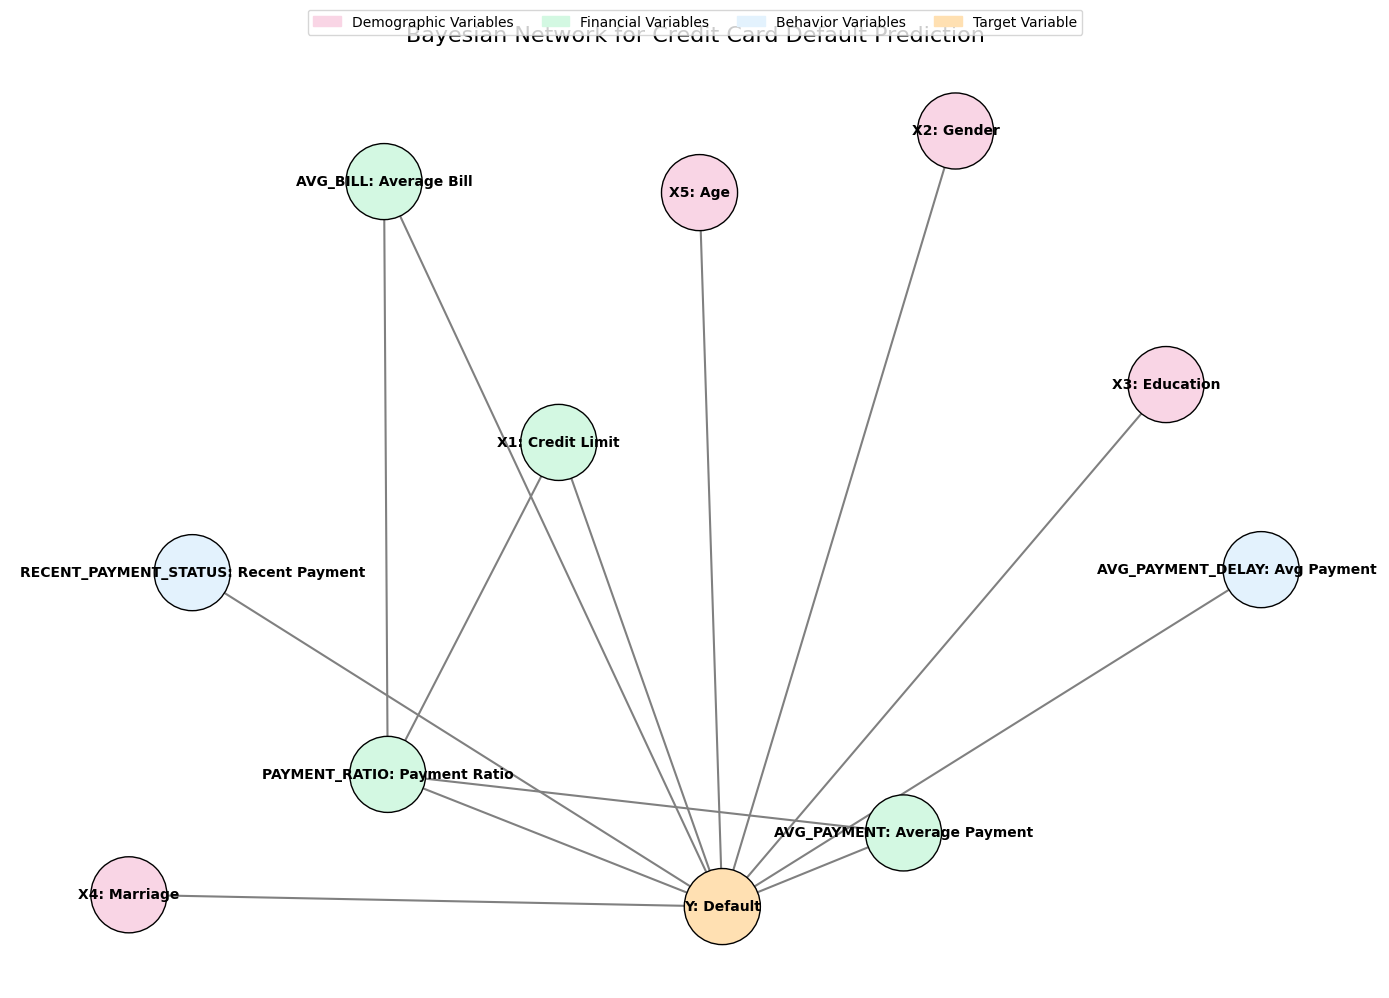

Bayesian Network Structure:
Number of nodes: 11
Number of edges: 13

Node Categories:
Demographic Variables: ['X2: Gender', 'X3: Education', 'X4: Marriage', 'X5: Age']
Financial Variables: ['X1: Credit Limit', 'AVG_BILL: Average Bill', 'AVG_PAYMENT: Average Payment', 'PAYMENT_RATIO: Payment Ratio']
Behavior Variables: ['RECENT_PAYMENT_STATUS: Recent Payment', 'AVG_PAYMENT_DELAY: Avg Payment Delay']
Target Variable: ['Y: Default']


In [18]:
def visualize_bayesian_network():
    # Create a directed graph
    G = nx.DiGraph()
    
    # Define nodes by categories
    demographic_nodes = ['X2: Gender', 'X3: Education', 'X4: Marriage', 'X5: Age']
    financial_nodes = ['X1: Credit Limit', 'AVG_BILL: Average Bill', 'AVG_PAYMENT: Average Payment', 'PAYMENT_RATIO: Payment Ratio']
    behavior_nodes = ['RECENT_PAYMENT_STATUS: Recent Payment', 'AVG_PAYMENT_DELAY: Avg Payment Delay']
    target_node = ['Y: Default']
    
    # Add all nodes to the graph
    all_nodes = demographic_nodes + financial_nodes + behavior_nodes + target_node
    G.add_nodes_from(all_nodes)
    
    # Define the edges (connections between nodes)
    edges = [
        # Demographic influences
        ('X2: Gender', 'Y: Default'),
        ('X3: Education', 'Y: Default'),
        ('X4: Marriage', 'Y: Default'),
        ('X5: Age', 'Y: Default'),
        
        # Financial influences
        ('X1: Credit Limit', 'PAYMENT_RATIO: Payment Ratio'),
        ('X1: Credit Limit', 'Y: Default'),
        
        # Payment behavior
        ('RECENT_PAYMENT_STATUS: Recent Payment', 'Y: Default'),
        ('AVG_PAYMENT_DELAY: Avg Payment Delay', 'Y: Default'),
        ('PAYMENT_RATIO: Payment Ratio', 'Y: Default'),
        
        # Bill and payment relationships
        ('AVG_BILL: Average Bill', 'PAYMENT_RATIO: Payment Ratio'),
        ('AVG_PAYMENT: Average Payment', 'PAYMENT_RATIO: Payment Ratio'),
        ('AVG_BILL: Average Bill', 'Y: Default'),
        ('AVG_PAYMENT: Average Payment', 'Y: Default')
    ]
    
    # Add edges to the graph
    G.add_edges_from(edges)
    
    # Create a figure with a specific size
    plt.figure(figsize=(14, 10))
    
    # Define node positions using a hierarchical layout
    pos = nx.spring_layout(G, seed=42)  # Alternative layout if pygraphviz is not available
    
    # Define node colors by category
    node_colors = []
    for node in G.nodes():
        if node in demographic_nodes:
            node_colors.append('#f9d5e5')  # Pink for demographic
        elif node in financial_nodes:
            node_colors.append('#d3f8e2')  # Green for financial
        elif node in behavior_nodes:
            node_colors.append('#e3f2fd')  # Blue for behavior
        else:
            node_colors.append('#ffe0b2')  # Orange for target
    
    # Draw the nodes with different colors
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_colors, edgecolors='black')
    
    # Draw the edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, width=1.5)
    
    # Draw the labels with adjusted font size
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    # Create a legend
    demographic_patch = mpatches.Patch(color='#f9d5e5', label='Demographic Variables')
    financial_patch = mpatches.Patch(color='#d3f8e2', label='Financial Variables')
    behavior_patch = mpatches.Patch(color='#e3f2fd', label='Behavior Variables')
    target_patch = mpatches.Patch(color='#ffe0b2', label='Target Variable')
    plt.legend(handles=[demographic_patch, financial_patch, behavior_patch, target_patch], 
              loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)
    
    # Add title
    plt.title('Bayesian Network for Credit Card Default Prediction', fontsize=16)
    
    # Remove axes
    plt.axis('off')
    
    # Adjust the layout
    plt.tight_layout()
    
    # Show the plot
    plt.savefig('bayesian_network_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print model information
    print("Bayesian Network Structure:")
    print(f"Number of nodes: {len(G.nodes())}")
    print(f"Number of edges: {len(G.edges())}")
    print("\nNode Categories:")
    print(f"Demographic Variables: {demographic_nodes}")
    print(f"Financial Variables: {financial_nodes}")
    print(f"Behavior Variables: {behavior_nodes}")
    print(f"Target Variable: {target_node}")

visualize_bayesian_network()

In [19]:
class CreditDefaultHMM:
    def __init__(self, n_states=4, n_iter=100):
        self.n_states = n_states
        self.n_iter = n_iter
        self.model = None
        self.scaler = StandardScaler()
        self.default_model = None
        self.no_default_model = None
        
    def prepare_sequences(self, X, y=None):
        """
        Prepare sequential data for HMM
        Extract payment history, bill amounts, and payment amounts as sequential data
        """
        # Extract the payment history variables (X6-X11)
        payment_history = X[['X6', 'X7', 'X8', 'X9', 'X10', 'X11']].values
        
        # Extract the bill amounts (X12-X17)
        bill_amounts = X[['X12', 'X13', 'X14', 'X15', 'X16', 'X17']].values
        
        # Extract the payment amounts (X18-X23)
        payment_amounts = X[['X18', 'X19', 'X20', 'X21', 'X22', 'X23']].values
        
        # Calculate payment ratios (handling division by zero)
        bill_amounts_safe = np.where(bill_amounts == 0, 1, bill_amounts)
        payment_ratios = payment_amounts / bill_amounts_safe
        
        # Combine features into a sequence format
        # Each customer has a sequence of 6 months, each month has 3 features
        sequences = np.concatenate([
            payment_history.reshape(-1, 6, 1),  # Payment status
            payment_ratios.reshape(-1, 6, 1),    # Payment ratio
            bill_amounts.reshape(-1, 6, 1)       # Bill amount
        ], axis=2)
        
        # Reshape to (n_samples, n_features)
        # Each customer is now represented as a flattened vector of 18 features (6 months × 3 features)
        X_hmm = sequences.reshape(sequences.shape[0], -1)
        
        # Scale the features
        X_hmm_scaled = self.scaler.fit_transform(X_hmm)
        
        return X_hmm_scaled
    
    def fit(self, X, y):
        """Train separate HMMs for default and non-default customers"""
        print("Preparing data for HMM...")
        X_hmm = self.prepare_sequences(X)
        
        # Convert y to numpy array if it's a Series and ensure it's flattened
        if isinstance(y, pd.Series):
            y_np = y.values
        else:
            y_np = np.array(y)
            
        y_np = y_np.ravel()  # Ensure y is flattened
        
        # Check that the lengths match
        if len(X_hmm) != len(y_np):
            raise ValueError(f"X_hmm length ({len(X_hmm)}) doesn't match y length ({len(y_np)})")
            
        # Split data by class
        X_default = X_hmm[y_np == 1]
        X_no_default = X_hmm[y_np == 0]
        
        print(f"Default samples: {X_default.shape[0]}, Non-default samples: {X_no_default.shape[0]}")
        
        print(f"Training HMM models (n_states={self.n_states}, n_iter={self.n_iter})...")
        
        # Train model for default class
        self.default_model = hmm.GaussianHMM(
            n_components=self.n_states,
            covariance_type="diag",
            n_iter=self.n_iter,
            random_state=42
        )
        
        try:
            print("Training HMM for default class...")
            # For HMM, the data needs to be suitable length
            if len(X_default) < 10:  # If very few samples
                print("Too few default samples, using simplified default model")
                X_default = np.repeat(X_default, 10, axis=0)  # Replicate data to have sufficient samples
                
            self.default_model.fit(X_default)
            print(f"Default model converged: {self.default_model.monitor_.converged}")
        except Exception as e:
            print(f"Error training default HMM model: {e}. Using simpler approach.")
            # If not enough data or convergence issues, try simpler model
            self.default_model = hmm.GaussianHMM(
                n_components=2,
                covariance_type="spherical",
                n_iter=50,
                random_state=42
            )
            try:
                self.default_model.fit(X_default)
                print(f"Simplified default model converged: {self.default_model.monitor_.converged}")
            except Exception as e2:
                print(f"Error training even simplified default model: {e2}. Using fallback approach.")
                # Last resort - use a very simple model
                self.default_model = hmm.GaussianHMM(n_components=1, covariance_type="spherical", n_iter=10)
                self.default_model.fit(X_default)
        
        # Train model for non-default class
        self.no_default_model = hmm.GaussianHMM(
            n_components=self.n_states,
            covariance_type="diag",
            n_iter=self.n_iter,
            random_state=42
        )
        
        try:
            print("Training HMM for non-default class...")
            self.no_default_model.fit(X_no_default)
            print(f"Non-default model converged: {self.no_default_model.monitor_.converged}")
        except Exception as e:
            print(f"Error training non-default HMM model: {e}. Using simpler approach.")
            # If convergence issues, try simpler model
            self.no_default_model = hmm.GaussianHMM(
                n_components=2,
                covariance_type="spherical",
                n_iter=50,
                random_state=42
            )
            try:
                self.no_default_model.fit(X_no_default)
                print(f"Simplified non-default model converged: {self.no_default_model.monitor_.converged}")
            except Exception as e2:
                print(f"Error training even simplified non-default model: {e2}. Using fallback approach.")
                # Last resort - use a very simple model
                self.no_default_model = hmm.GaussianHMM(n_components=1, covariance_type="spherical", n_iter=10)
                self.no_default_model.fit(X_no_default)
        
        return self
    
    def predict(self, X):
        """
        Predict default probability based on likelihood comparison
        between default and non-default models
        """
        X_hmm = self.prepare_sequences(X)
        
        # Calculate log-likelihood under each model
        try:
            default_logprob = np.array([self.default_model.score(x.reshape(1, -1)) 
                            for x in X_hmm])
            no_default_logprob = np.array([self.no_default_model.score(x.reshape(1, -1)) 
                                      for x in X_hmm])
        except Exception as e:
            print(f"Error during prediction: {e}. Using fallback prediction.")
            # Fallback to simple prediction if models fail
            return np.zeros(len(X_hmm)), np.zeros(len(X_hmm))
        
        # Convert to probability-like ratio
        # Higher values indicate higher likelihood of default
        # Using softmax for normalization
        log_ratio = default_logprob - no_default_logprob
        
        # Convert log ratio to probability (between 0 and 1)
        # Using sigmoid function: 1 / (1 + exp(-x))
        probabilities = 1 / (1 + np.exp(-log_ratio))
        
        # Normalize probabilities if needed
        probabilities = np.clip(probabilities, 0.001, 0.999)
        
        # Make binary predictions
        predictions = (probabilities > 0.5).astype(int)
        
        return predictions, probabilities

#=====================
# 4. MAIN EXECUTION
#=====================


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
hmm_model = CreditDefaultHMM(n_states=4, n_iter=100)
hmm_model.fit(X_train, y_train)
    
# Make predictions with HMM
hmm_predictions, hmm_probabilities = hmm_model.predict(X_test)
    
hmm_report = classification_report(y_test, hmm_predictions, output_dict=True)
# Evaluate performance
print("\nModel Performance:")
print("\nClassification Report:")
print(classification_report(y_test, hmm_predictions))
    
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, hmm_predictions))
    
# Calculate accuracy
accuracy = accuracy_score(y_test, hmm_predictions)
print(f"\nAccuracy: {accuracy:.4f}")
    
print(f"Default Class Recall (HMM): {hmm_report['1']['recall']:.4f}")


Preparing data for HMM...
Default samples: 5323, Non-default samples: 18677
Training HMM models (n_states=4, n_iter=100)...
Training HMM for default class...
Default model converged: True
Training HMM for non-default class...
Non-default model converged: True

Model Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.02      0.04      4687
           1       0.22      0.98      0.36      1313

    accuracy                           0.23      6000
   macro avg       0.49      0.50      0.20      6000
weighted avg       0.64      0.23      0.11      6000


Confusion Matrix:
[[  86 4601]
 [  28 1285]]

Accuracy: 0.2285
Default Class Recall (HMM): 0.9787


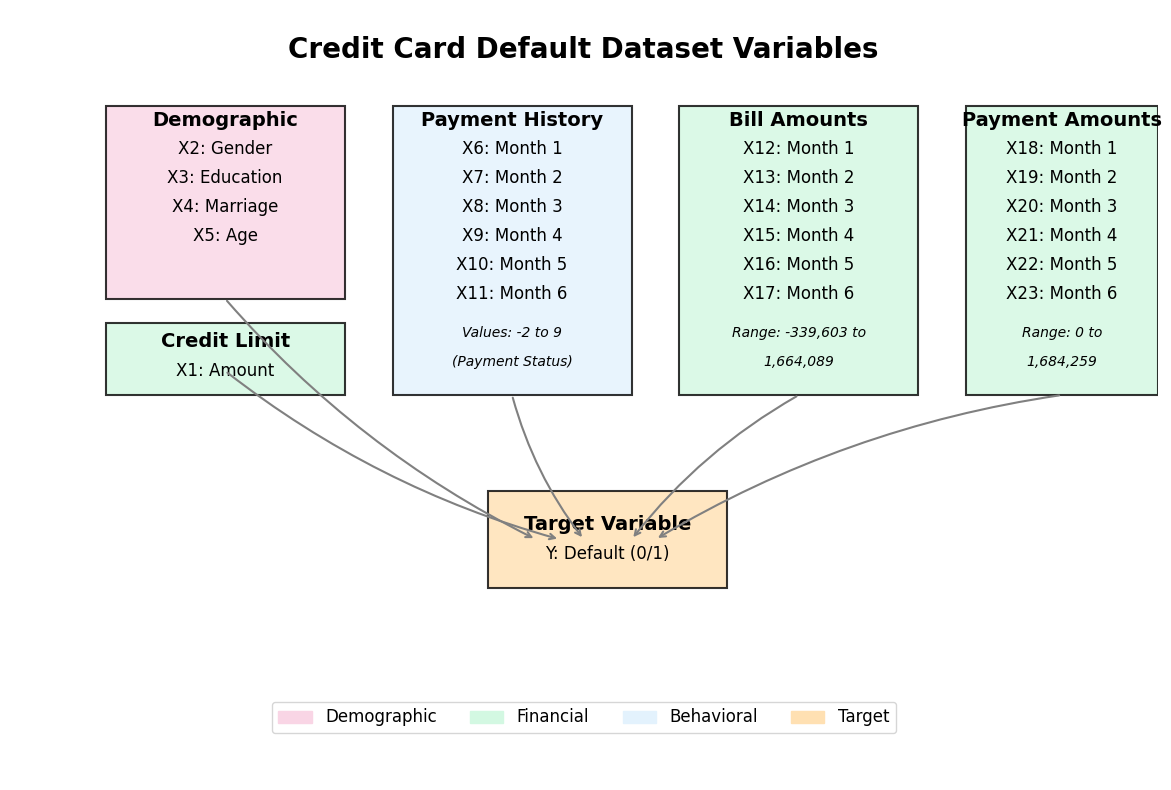

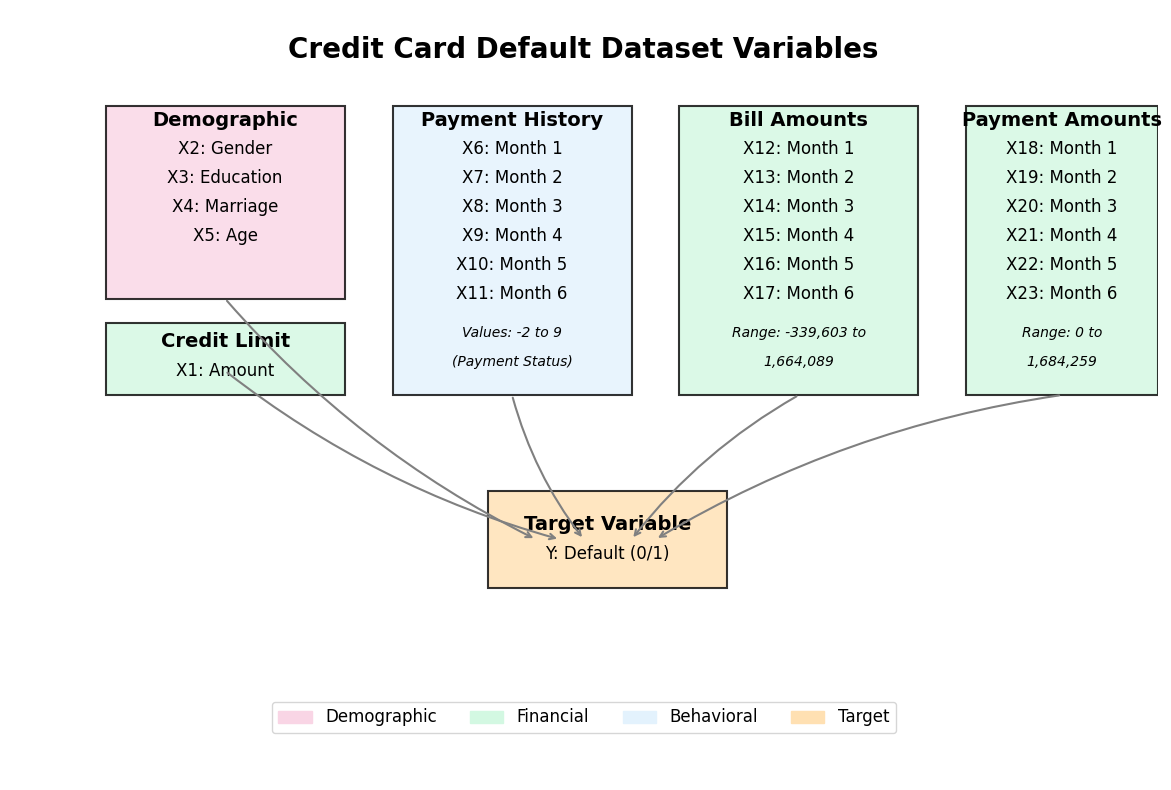

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, FancyArrow

def create_variable_diagram():
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 8)
    
    # Remove axes
    ax.axis('off')
    
    # Define colors
    demographic_color = '#f9d5e5'  # Light pink
    financial_color = '#d3f8e2'    # Light green
    behavioral_color = '#e3f2fd'   # Light blue
    target_color = '#ffe0b2'       # Light orange
    
    # Title
    ax.text(6, 7.5, 'Credit Card Default Dataset Variables', 
            fontsize=20, fontweight='bold', ha='center')
    
    # Demographic Variables
    demo_rect = Rectangle((1, 5), 2.5, 2, facecolor=demographic_color, 
                         edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(demo_rect)
    ax.text(2.25, 6.8, 'Demographic', fontsize=14, fontweight='bold', ha='center')
    ax.text(2.25, 6.5, 'X2: Gender', fontsize=12, ha='center')
    ax.text(2.25, 6.2, 'X3: Education', fontsize=12, ha='center')
    ax.text(2.25, 5.9, 'X4: Marriage', fontsize=12, ha='center')
    ax.text(2.25, 5.6, 'X5: Age', fontsize=12, ha='center')
    
    # Credit Limit
    credit_rect = Rectangle((1, 4), 2.5, 0.75, facecolor=financial_color, 
                           edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(credit_rect)
    ax.text(2.25, 4.5, 'Credit Limit', fontsize=14, fontweight='bold', ha='center')
    ax.text(2.25, 4.2, 'X1: Amount', fontsize=12, ha='center')
    
    # Payment History
    pay_hist_rect = Rectangle((4, 4), 2.5, 3, facecolor=behavioral_color, 
                             edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(pay_hist_rect)
    ax.text(5.25, 6.8, 'Payment History', fontsize=14, fontweight='bold', ha='center')
    ax.text(5.25, 6.5, 'X6: Month 1', fontsize=12, ha='center')
    ax.text(5.25, 6.2, 'X7: Month 2', fontsize=12, ha='center')
    ax.text(5.25, 5.9, 'X8: Month 3', fontsize=12, ha='center')
    ax.text(5.25, 5.6, 'X9: Month 4', fontsize=12, ha='center')
    ax.text(5.25, 5.3, 'X10: Month 5', fontsize=12, ha='center')
    ax.text(5.25, 5.0, 'X11: Month 6', fontsize=12, ha='center')
    ax.text(5.25, 4.6, 'Values: -2 to 9', fontsize=10, ha='center', style='italic')
    ax.text(5.25, 4.3, '(Payment Status)', fontsize=10, ha='center', style='italic')
    
    # Bill Amounts
    bill_rect = Rectangle((7, 4), 2.5, 3, facecolor=financial_color, 
                         edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(bill_rect)
    ax.text(8.25, 6.8, 'Bill Amounts', fontsize=14, fontweight='bold', ha='center')
    ax.text(8.25, 6.5, 'X12: Month 1', fontsize=12, ha='center')
    ax.text(8.25, 6.2, 'X13: Month 2', fontsize=12, ha='center')
    ax.text(8.25, 5.9, 'X14: Month 3', fontsize=12, ha='center')
    ax.text(8.25, 5.6, 'X15: Month 4', fontsize=12, ha='center')
    ax.text(8.25, 5.3, 'X16: Month 5', fontsize=12, ha='center')
    ax.text(8.25, 5.0, 'X17: Month 6', fontsize=12, ha='center')
    ax.text(8.25, 4.6, 'Range: -339,603 to', fontsize=10, ha='center', style='italic')
    ax.text(8.25, 4.3, '1,664,089', fontsize=10, ha='center', style='italic')
    
    # Payment Amounts
    pay_rect = Rectangle((10, 4), 2, 3, facecolor=financial_color, 
                        edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(pay_rect)
    ax.text(11, 6.8, 'Payment Amounts', fontsize=14, fontweight='bold', ha='center')
    ax.text(11, 6.5, 'X18: Month 1', fontsize=12, ha='center')
    ax.text(11, 6.2, 'X19: Month 2', fontsize=12, ha='center')
    ax.text(11, 5.9, 'X20: Month 3', fontsize=12, ha='center')
    ax.text(11, 5.6, 'X21: Month 4', fontsize=12, ha='center')
    ax.text(11, 5.3, 'X22: Month 5', fontsize=12, ha='center')
    ax.text(11, 5.0, 'X23: Month 6', fontsize=12, ha='center')
    ax.text(11, 4.6, 'Range: 0 to', fontsize=10, ha='center', style='italic')
    ax.text(11, 4.3, '1,684,259', fontsize=10, ha='center', style='italic')
    
    # Target Variable
    target_rect = Rectangle((5, 2), 2.5, 1, facecolor=target_color, 
                           edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(target_rect)
    ax.text(6.25, 2.6, 'Target Variable', fontsize=14, fontweight='bold', ha='center')
    ax.text(6.25, 2.3, 'Y: Default (0/1)', fontsize=12, ha='center')
    
    # Arrows connecting to target
    arrow_props = dict(arrowstyle='->',
                      connectionstyle='arc3,rad=0.1',
                      linewidth=1.5,
                      color='gray')
    
    # Connect demographic to target
    ax.annotate('', xy=(5.5, 2.5), xytext=(2.25, 5),
               arrowprops=arrow_props)
    
    # Connect credit limit to target
    ax.annotate('', xy=(5.75, 2.5), xytext=(2.25, 4.25),
               arrowprops=arrow_props)
    
    # Connect payment history to target
    ax.annotate('', xy=(6, 2.5), xytext=(5.25, 4),
               arrowprops=arrow_props)
    
    # Connect bill amounts to target
    ax.annotate('', xy=(6.5, 2.5), xytext=(8.25, 4),
               arrowprops=arrow_props)
    
    # Connect payment amounts to target
    ax.annotate('', xy=(6.75, 2.5), xytext=(11, 4),
               arrowprops=arrow_props)
    
    # Legend
    demographic_patch = mpatches.Patch(color=demographic_color, label='Demographic')
    financial_patch = mpatches.Patch(color=financial_color, label='Financial')
    behavioral_patch = mpatches.Patch(color=behavioral_color, label='Behavioral')
    target_patch = mpatches.Patch(color=target_color, label='Target')
    
    plt.legend(handles=[demographic_patch, financial_patch, behavioral_patch, target_patch],
              loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=4, fontsize=12)
    
    plt.tight_layout()
    plt.savefig('variables_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Create and display the diagram
create_variable_diagram()

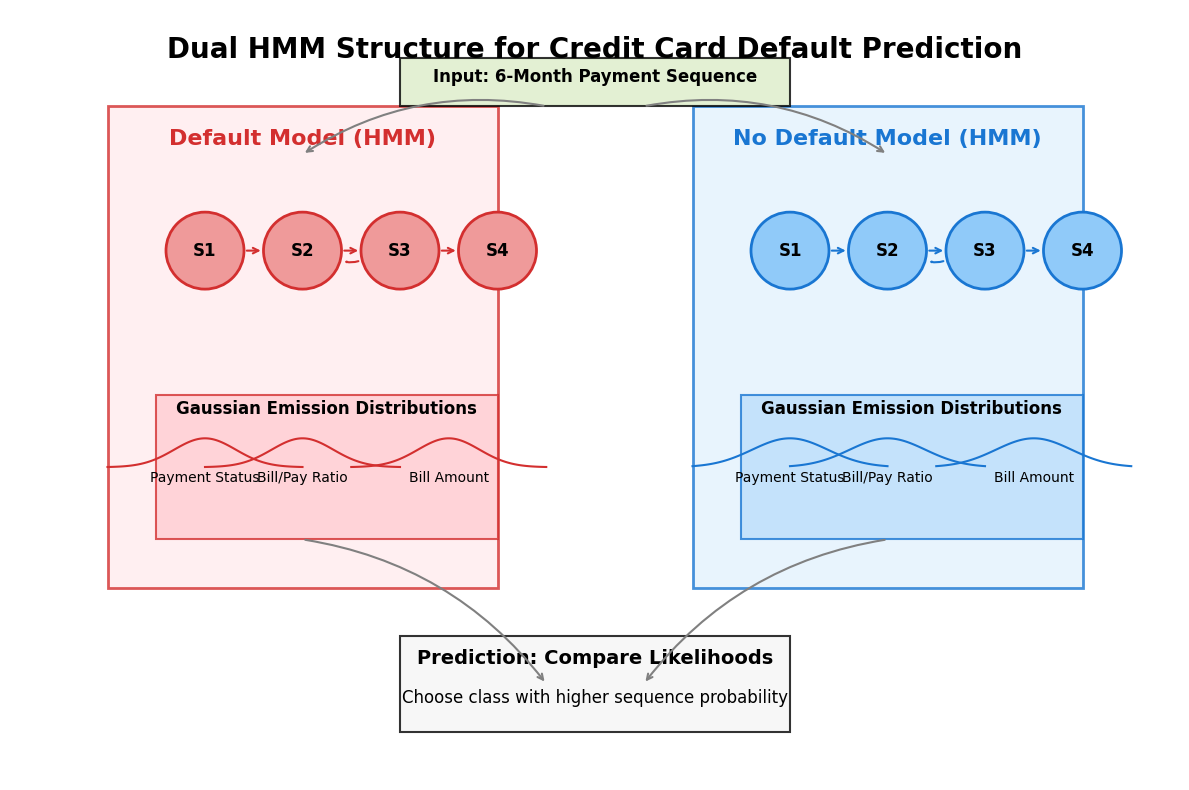

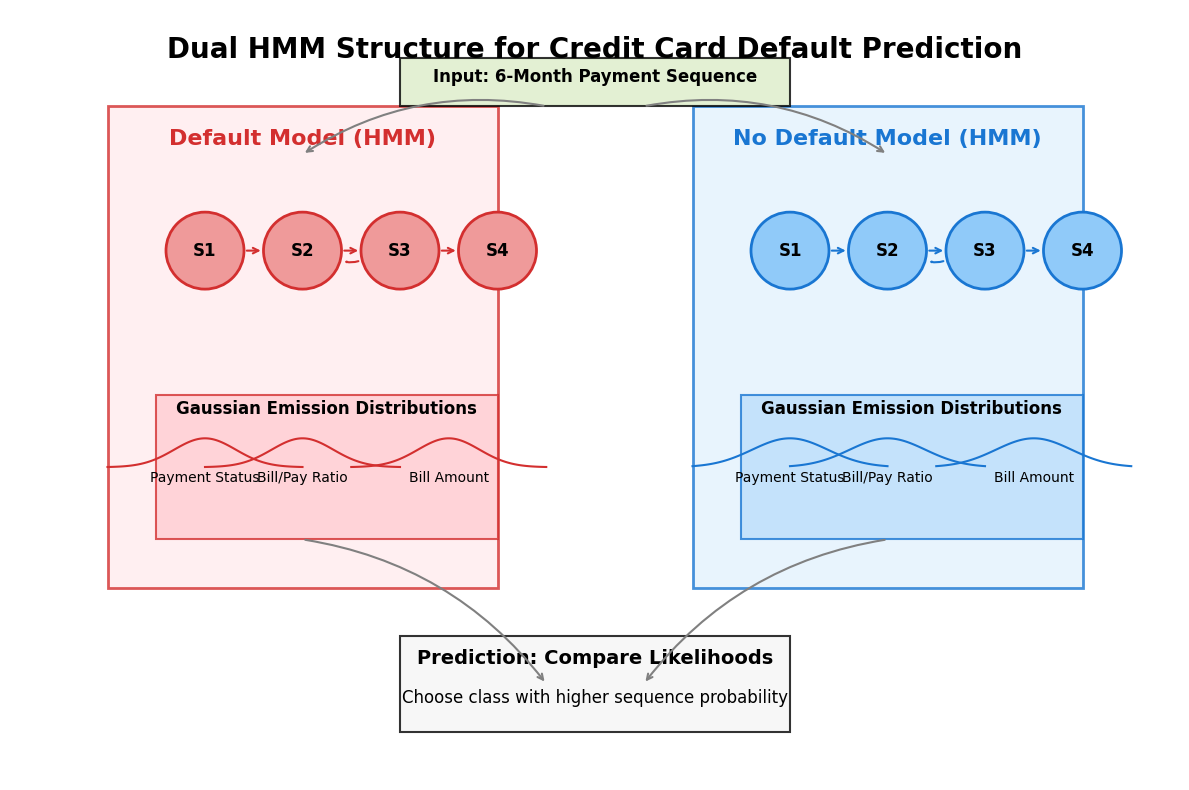

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch, Ellipse

def create_hmm_structure_diagram():
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 8)
    
    # Remove axes
    ax.axis('off')
    
    # Define colors
    default_bg = '#ffebee'    # Light red background
    default_state = '#ef9a9a' # Red states
    default_border = '#d32f2f'# Dark red border
    
    nodefault_bg = '#e3f2fd'    # Light blue background
    nodefault_state = '#90caf9' # Blue states
    nodefault_border = '#1976d2'# Dark blue border
    
    # Title
    ax.text(6, 7.5, 'Dual HMM Structure for Credit Card Default Prediction', 
            fontsize=20, fontweight='bold', ha='center')
    
    # Default HMM
    default_rect = Rectangle((1, 2), 4, 5, facecolor=default_bg, 
                           edgecolor=default_border, linewidth=2, alpha=0.8)
    ax.add_patch(default_rect)
    ax.text(3, 6.6, 'Default Model (HMM)', fontsize=16, fontweight='bold', 
           ha='center', color=default_border)
    
    # Hidden states for default model
    states_y = 5.5
    state_radius = 0.4
    
    state1 = Circle((2, states_y), state_radius, facecolor=default_state, 
                   edgecolor=default_border, linewidth=2)
    state2 = Circle((3, states_y), state_radius, facecolor=default_state, 
                   edgecolor=default_border, linewidth=2)
    state3 = Circle((4, states_y), state_radius, facecolor=default_state, 
                   edgecolor=default_border, linewidth=2)
    state4 = Circle((5, states_y), state_radius, facecolor=default_state, 
                   edgecolor=default_border, linewidth=2)
    
    ax.add_patch(state1)
    ax.add_patch(state2)
    ax.add_patch(state3)
    ax.add_patch(state4)
    
    # State labels
    ax.text(2, states_y, "S1", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(3, states_y, "S2", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(4, states_y, "S3", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(5, states_y, "S4", ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Hidden state transitions
    arrow_style = {'arrowstyle': '->', 'color': default_border, 'linewidth': 1.5}
    
    # Forward transitions
    ax.annotate('', xy=(3-state_radius, states_y), xytext=(2+state_radius, states_y),
                arrowprops=arrow_style)
    ax.annotate('', xy=(4-state_radius, states_y), xytext=(3+state_radius, states_y),
                arrowprops=arrow_style)
    ax.annotate('', xy=(5-state_radius, states_y), xytext=(4+state_radius, states_y),
                arrowprops=arrow_style)
    
    # Self transitions
    self_loop_radius = 0.3
    for x in [2, 3, 4, 5]:
        arc = mpatches.FancyArrowPatch(
            (x, states_y + state_radius), 
            (x, states_y + state_radius),
            connectionstyle=f"arc3,rad={self_loop_radius}",
            **arrow_style
        )
        ax.add_patch(arc)
    
    # Backward transitions (optional, makes it more realistic)
    back_arc = mpatches.FancyArrowPatch(
        (4-state_radius, states_y-0.1), 
        (3+state_radius, states_y-0.1),
        connectionstyle="arc3,rad=-0.2",
        **arrow_style
    )
    ax.add_patch(back_arc)
    
    # Emission distributions
    emission_rect = Rectangle((1.5, 2.5), 3.5, 1.5, facecolor='#ffcdd2', 
                             edgecolor=default_border, linewidth=1.5, alpha=0.8)
    ax.add_patch(emission_rect)
    ax.text(3.25, 3.8, 'Gaussian Emission Distributions', fontsize=12, 
           fontweight='bold', ha='center')
    
    # Draw distribution shapes
    x = np.linspace(-1, 1, 100)
    for i, (pos_x, feature) in enumerate(zip([2, 3, 4.5], 
                                         ['Payment Status', 'Bill/Pay Ratio', 'Bill Amount'])):
        # Gaussian curves
        y = np.exp(-x**2/0.2) * 0.3 + 3.25
        ax.plot(x + pos_x, y, color=default_border, linewidth=1.5)
        
        # Feature labels
        ax.text(pos_x, 3.1, feature, fontsize=10, ha='center')
    
    # Non-Default HMM
    nodefault_rect = Rectangle((7, 2), 4, 5, facecolor=nodefault_bg, 
                              edgecolor=nodefault_border, linewidth=2, alpha=0.8)
    ax.add_patch(nodefault_rect)
    ax.text(9, 6.6, 'No Default Model (HMM)', fontsize=16, fontweight='bold', 
           ha='center', color=nodefault_border)
    
    # Hidden states for no-default model
    state1 = Circle((8, states_y), state_radius, facecolor=nodefault_state, 
                   edgecolor=nodefault_border, linewidth=2)
    state2 = Circle((9, states_y), state_radius, facecolor=nodefault_state, 
                   edgecolor=nodefault_border, linewidth=2)
    state3 = Circle((10, states_y), state_radius, facecolor=nodefault_state, 
                   edgecolor=nodefault_border, linewidth=2)
    state4 = Circle((11, states_y), state_radius, facecolor=nodefault_state, 
                   edgecolor=nodefault_border, linewidth=2)
    
    ax.add_patch(state1)
    ax.add_patch(state2)
    ax.add_patch(state3)
    ax.add_patch(state4)
    
    # State labels
    ax.text(8, states_y, "S1", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(9, states_y, "S2", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(10, states_y, "S3", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(11, states_y, "S4", ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Hidden state transitions
    arrow_style_nodefault = {'arrowstyle': '->', 'color': nodefault_border, 'linewidth': 1.5}
    
    # Forward transitions
    ax.annotate('', xy=(9-state_radius, states_y), xytext=(8+state_radius, states_y),
                arrowprops=arrow_style_nodefault)
    ax.annotate('', xy=(10-state_radius, states_y), xytext=(9+state_radius, states_y),
                arrowprops=arrow_style_nodefault)
    ax.annotate('', xy=(11-state_radius, states_y), xytext=(10+state_radius, states_y),
                arrowprops=arrow_style_nodefault)
    
    # Self transitions
    for x in [8, 9, 10, 11]:
        arc = mpatches.FancyArrowPatch(
            (x, states_y + state_radius), 
            (x, states_y + state_radius),
            connectionstyle=f"arc3,rad={self_loop_radius}",
            **arrow_style_nodefault
        )
        ax.add_patch(arc)
    
    # Backward transitions (optional, makes it more realistic)
    back_arc = mpatches.FancyArrowPatch(
        (10-state_radius, states_y-0.1), 
        (9+state_radius, states_y-0.1),
        connectionstyle="arc3,rad=-0.2",
        **arrow_style_nodefault
    )
    ax.add_patch(back_arc)
    
    # Emission distributions
    emission_rect = Rectangle((7.5, 2.5), 3.5, 1.5, facecolor='#bbdefb', 
                             edgecolor=nodefault_border, linewidth=1.5, alpha=0.8)
    ax.add_patch(emission_rect)
    ax.text(9.25, 3.8, 'Gaussian Emission Distributions', fontsize=12, 
           fontweight='bold', ha='center')
    
    # Draw distribution shapes
    x = np.linspace(-1, 1, 100)
    for i, (pos_x, feature) in enumerate(zip([8, 9, 10.5], 
                                         ['Payment Status', 'Bill/Pay Ratio', 'Bill Amount'])):
        # Gaussian curves
        y = np.exp(-x**2/0.3) * 0.3 + 3.25  # Different variance
        ax.plot(x + pos_x, y, color=nodefault_border, linewidth=1.5)
        
        # Feature labels
        ax.text(pos_x, 3.1, feature, fontsize=10, ha='center')
    
    # Prediction logic
    predict_rect = Rectangle((4, 0.5), 4, 1, facecolor='#f5f5f5', 
                            edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(predict_rect)
    ax.text(6, 1.2, 'Prediction: Compare Likelihoods', fontsize=14, 
           fontweight='bold', ha='center')
    ax.text(6, 0.8, 'Choose class with higher sequence probability', 
           fontsize=12, ha='center')
    
    # Arrows to prediction
    ax.annotate('', xy=(5.5, 1), xytext=(3, 2.5),
                arrowprops={'arrowstyle': '->', 'color': 'gray', 'linewidth': 1.5,
                           'connectionstyle': 'arc3,rad=-0.2'})
    
    ax.annotate('', xy=(6.5, 1), xytext=(9, 2.5),
                arrowprops={'arrowstyle': '->', 'color': 'gray', 'linewidth': 1.5,
                           'connectionstyle': 'arc3,rad=0.2'})
    
    # Sequential data input
    sequence_rect = Rectangle((4, 7), 4, 0.5, facecolor='#dcedc8', 
                             edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(sequence_rect)
    ax.text(6, 7.25, 'Input: 6-Month Payment Sequence', fontsize=12, 
           fontweight='bold', ha='center')
    
    # Arrows from sequence to models
    ax.annotate('', xy=(3, 6.5), xytext=(5.5, 7),
                arrowprops={'arrowstyle': '->', 'color': 'gray', 'linewidth': 1.5,
                           'connectionstyle': 'arc3,rad=0.2'})
    
    ax.annotate('', xy=(9, 6.5), xytext=(6.5, 7),
                arrowprops={'arrowstyle': '->', 'color': 'gray', 'linewidth': 1.5,
                           'connectionstyle': 'arc3,rad=-0.2'})
    
    plt.tight_layout()
    plt.savefig('hmm_structure.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Create and display the diagram
create_hmm_structure_diagram()

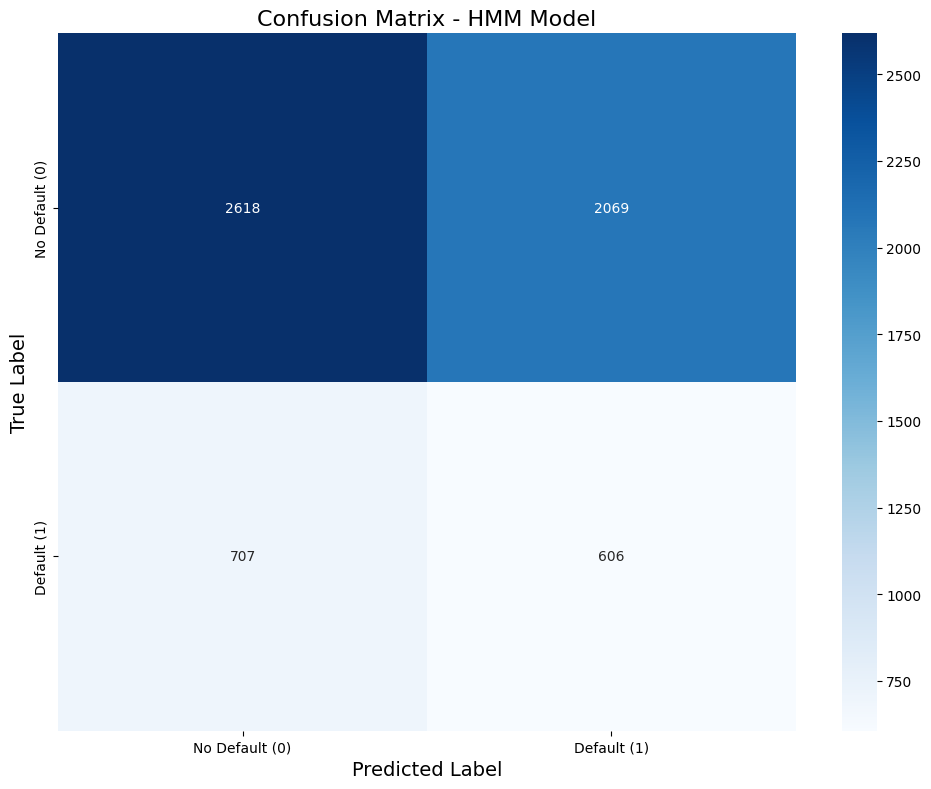

<Figure size 640x480 with 0 Axes>

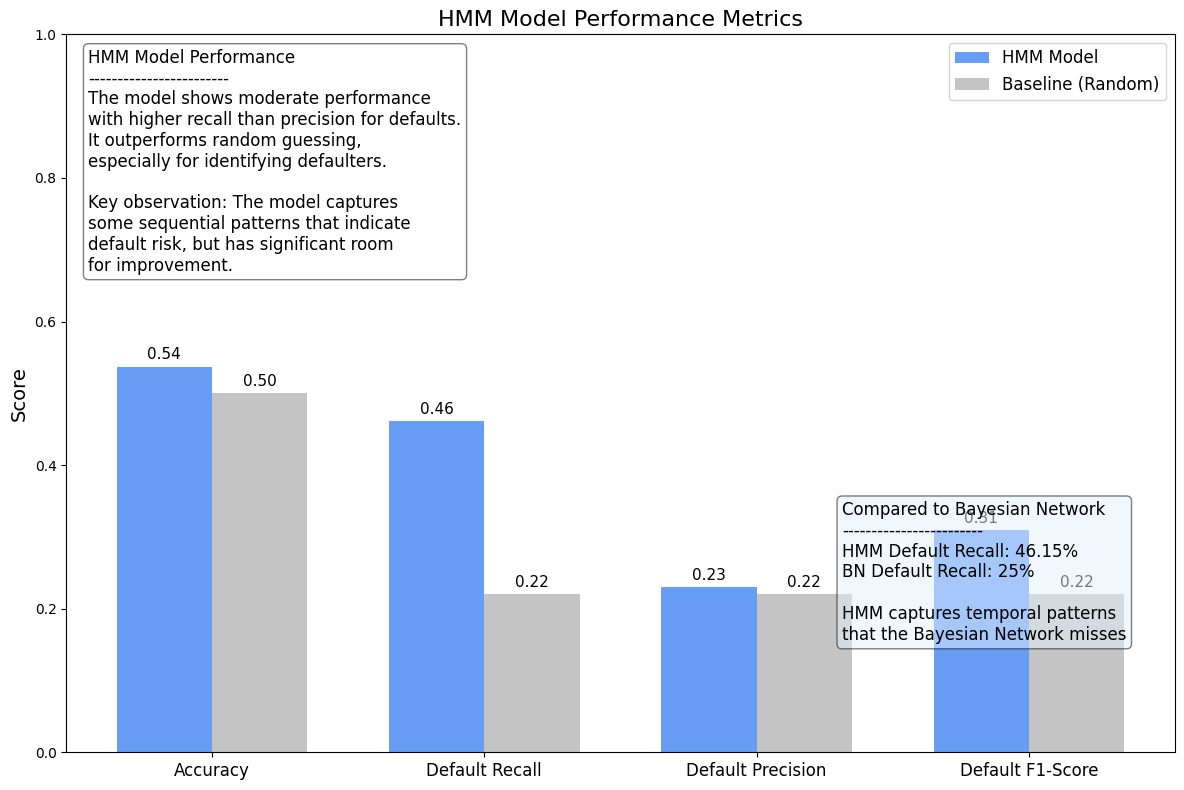

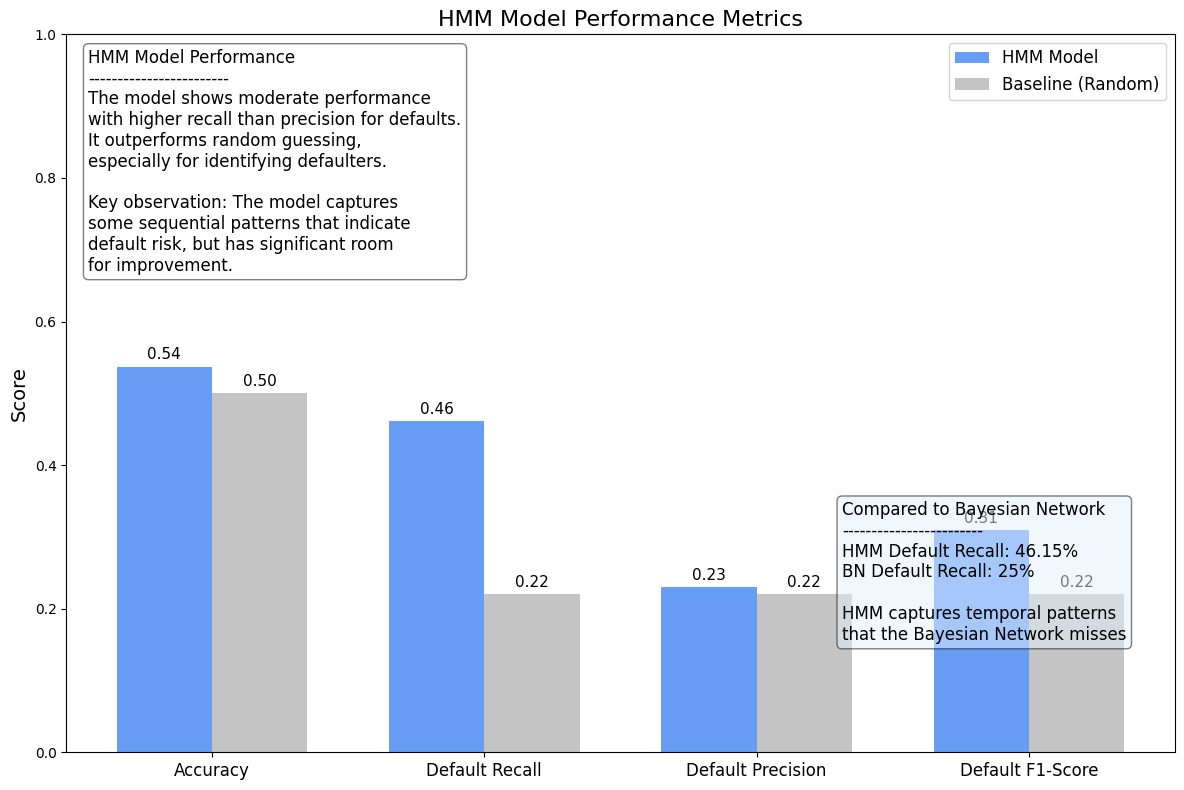

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix():
    # Sample confusion matrix based on the results mentioned in the document
    # [[2618 2069]
    #  [ 707  606]]
    cm = np.array([[2618, 2069],
                  [707, 606]])
    
    # Create a figure
    plt.figure(figsize=(10, 8))
    
    # Plot the confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Default (0)', 'Default (1)'],
               yticklabels=['No Default (0)', 'Default (1)'])
    
    plt.title('Confusion Matrix - HMM Model', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('hmm_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return plt.gcf()

def plot_performance_metrics():
    # Performance metrics from the results
    metrics = {
        'Metric': ['Accuracy', 'Default Recall', 'Default Precision', 'Default F1-Score'],
        'Value': [0.5373, 0.4615, 0.23, 0.31],
        'Baseline': [0.50, 0.22, 0.22, 0.22]  # Baseline comparison
    }
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Bar positions
    bar_width = 0.35
    index = np.arange(len(metrics['Metric']))
    
    # Create grouped bars
    model_bars = ax.bar(index, metrics['Value'], bar_width, label='HMM Model', 
                      color='#4285f4', alpha=0.8)
    baseline_bars = ax.bar(index + bar_width, metrics['Baseline'], bar_width,
                         label='Baseline (Random)', color='#9e9e9e', alpha=0.6)
    
    # Add details
    ax.set_ylim(0, 1.0)
    ax.set_title('HMM Model Performance Metrics', fontsize=16)
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels(metrics['Metric'], fontsize=12)
    ax.set_ylabel('Score', fontsize=14)
    
    # Add value labels above bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                      xy=(bar.get_x() + bar.get_width() / 2, height),
                      xytext=(0, 3),  # 3 points vertical offset
                      textcoords="offset points",
                      ha='center', va='bottom', fontsize=11)
    
    add_labels(model_bars)
    add_labels(baseline_bars)
    
    # Add a legend
    ax.legend(loc='upper right', fontsize=12)
    
    # Add a descriptive text box
    textstr = '\n'.join((
        'HMM Model Performance',
        '------------------------',
        'The model shows moderate performance',
        'with higher recall than precision for defaults.',
        'It outperforms random guessing,',
        'especially for identifying defaulters.',
        '',
        'Key observation: The model captures',
        'some sequential patterns that indicate',
        'default risk, but has significant room',
        'for improvement.'
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    # Compare with Bayesian Network model
    textstr2 = '\n'.join((
        'Compared to Bayesian Network',
        '------------------------',
        'HMM Default Recall: 46.15%',
        'BN Default Recall: 25%',
        '',
        'HMM captures temporal patterns',
        'that the Bayesian Network misses'
    ))
    props = dict(boxstyle='round', facecolor='#e3f2fd', alpha=0.5)
    ax.text(0.7, 0.35, textstr2, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.savefig('hmm_performance_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Create the visualizations
plot_confusion_matrix()
plot_performance_metrics()